# Decision Tree Classification -- End to End with the Adult Income Dataset

Logistic regression draws a single smooth boundary through the feature space. A **decision tree** takes a completely different approach: it predicts a category by asking a sequence of simple yes/no questions -- *"Is education-num > 12? Is the person married? Are capital gains above 7,000?"* -- and following the answers down to a leaf.

That makes trees:

- **Interpretable.** The whole model is a flowchart you can read top to bottom.
- **Non-linear and interaction-aware.** A tree can carve the space into arbitrary axis-aligned rectangles, so it captures "high education *and* married" without us hand-engineering the interaction.
- **Scale-free.** Splits depend only on the *ordering* of values, so we don't have to standardise anything.

The price is a tendency to **overfit** -- a deep enough tree can memorise the training set. Much of this notebook is about seeing that happen and controlling it.

**The dataset.** We'll use the same classic *Adult Income* dataset from the US Census. The task: predict whether a person earns more than \$50,000 a year (`>50K`) or not (`<=50K`).

## 1. Import Libraries

Three groups of imports:
- **Data + plotting:** pandas, numpy, matplotlib, seaborn.
- **Modelling:** scikit-learn's `DecisionTreeClassifier`, the train/test splitter, plus `plot_tree` and `export_text` for visualising the fitted tree.
- **Evaluation:** the usual classification metrics.

Notice what's *missing* compared to a logistic-regression notebook: there's **no `StandardScaler`**. Trees don't need it.

In [1]:
! pip install seaborn scikit-learn graphviz


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
import warnings
warnings.filterwarnings('ignore')

# visual defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load the Dataset

The Adult Income dataset is hosted on OpenML, a public repository of ML datasets. It has 48,842 rows and 15 columns. Missing values are encoded as `?`, so we'll tell pandas to treat that as NaN.

In [3]:
"""
fnlwgt is the Census Bureau's estimate of how many people in the total US population that particular row represents.

In other words: if a row has fnlwgt = 200000, the Census Bureau believes that this one sampled individual is statistically
representative of roughly 200,000 people in the actual population sharing similar demographic characteristics.
"""

"\nfnlwgt is the Census Bureau's estimate of how many people in the total US population that particular row represents.\n\nIn other words: if a row has fnlwgt = 200000, the Census Bureau believes that this one sampled individual is statistically\nrepresentative of roughly 200,000 people in the actual population sharing similar demographic characteristics.\n"

In [4]:
url = "https://www.openml.org/data/get_csv/1595261/phpMawTba"
df = pd.read_csv(url, na_values=['?', ' ?'], skipinitialspace=True)

# the target column is called "class" in the source — rename it for clarity
df.rename(columns={'class': 'income'}, inplace=True)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 48,842 rows and 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


Each row is one person. The features mix:
- **Numeric:** `age`, `fnlwgt` (a census sampling weight), `education-num` (years of education), `capital-gain`, `capital-loss`, `hours-per-week`
- **Categorical:** `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`

The target `income` takes two values: `<=50K` and `>50K`. We're trying to predict which one.

## 3. Data Description

Before any modelling, we need to know what we're working with. We'll check four things in turn:

1. Types and shape
2. Missing values
3. Summary statistics
4. **Class balance** — this is critical for classification

### 3.1 Types and shape

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


6 numeric columns and 9 object (string) columns. Note the non-null counts -- a few columns clearly have missing values.

### 3.2 Missing values

In [6]:
missing = df.isnull().sum()
missing[missing > 0].to_frame('missing_count').assign(pct=lambda d: (d['missing_count'] / len(df) * 100).round(2))

,missing_count,pct
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


Only three columns have missing data, and never more than ~6% of rows. We'll drop those rows later -- the simplest defensible choice on a dataset this size. (Imputation would also work, but adds complexity we don't need here.)

### 3.3 Summary statistics

In [7]:
df.describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


Notice the wild range of scales: `fnlwgt` runs into the hundreds of thousands, `age` is in the tens, `capital-gain` is mostly zero with occasional huge values.

For logistic regression these different magnitudes would force us to standardise. **A decision tree doesn't care** -- it only ever asks "is this feature above or below some threshold?", and that question is unaffected by the units. So we'll leave the raw values exactly as they are.

### 3.4 Class balance -- the most important diagnostic for classification

In [8]:
class_counts = df['income'].value_counts(dropna=False)
class_pct    = df['income'].value_counts(normalize=True).round(3) * 100

print("Class distribution:")
for cls in class_counts.index:
    print(f"  {cls!s:>8s} : {class_counts[cls]:>6,} ({class_pct[cls]:.1f}%)")

Class distribution:
     <=50K : 37,155 (76.1%)
      >50K : 11,687 (23.9%)


About **76% earn ≤\$50K and 24% earn >\$50K**. The dataset is *imbalanced* -- the two classes aren't represented equally. That has two practical implications:

- **Accuracy alone is misleading.** A model that always says "≤\$50K" would already be 76% accurate without learning anything.
- **We should look at precision, recall, F1, and ROC-AUC** instead -- they don't reward a lazy majority-class prediction.

We'll also use *stratified* sampling when we split into train/test, so that the class ratio is preserved on both sides.

## 4. Exploratory Data Analysis

Now we dig into the relationships between features and the target. The key question: **which features separate the two income groups?** Those are exactly the features a decision tree will reach for when it picks its splits.

For numeric features that means comparing the two class-conditional distributions. For categorical features it means looking at the high-income rate within each category.

### 4.1 The target itself

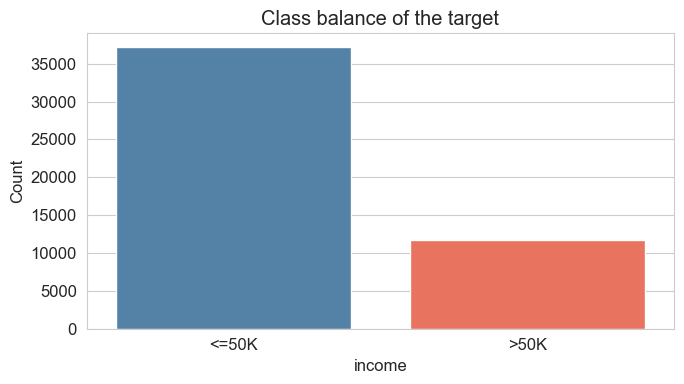

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='income', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Class balance of the target')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Numeric features by class

We'll overlay class-conditional histograms. Where the blue (≤\$50K) and red (>\$50K) distributions diverge, the feature carries signal -- and the tree will be able to find a threshold that separates them. Where they overlap, it doesn't.

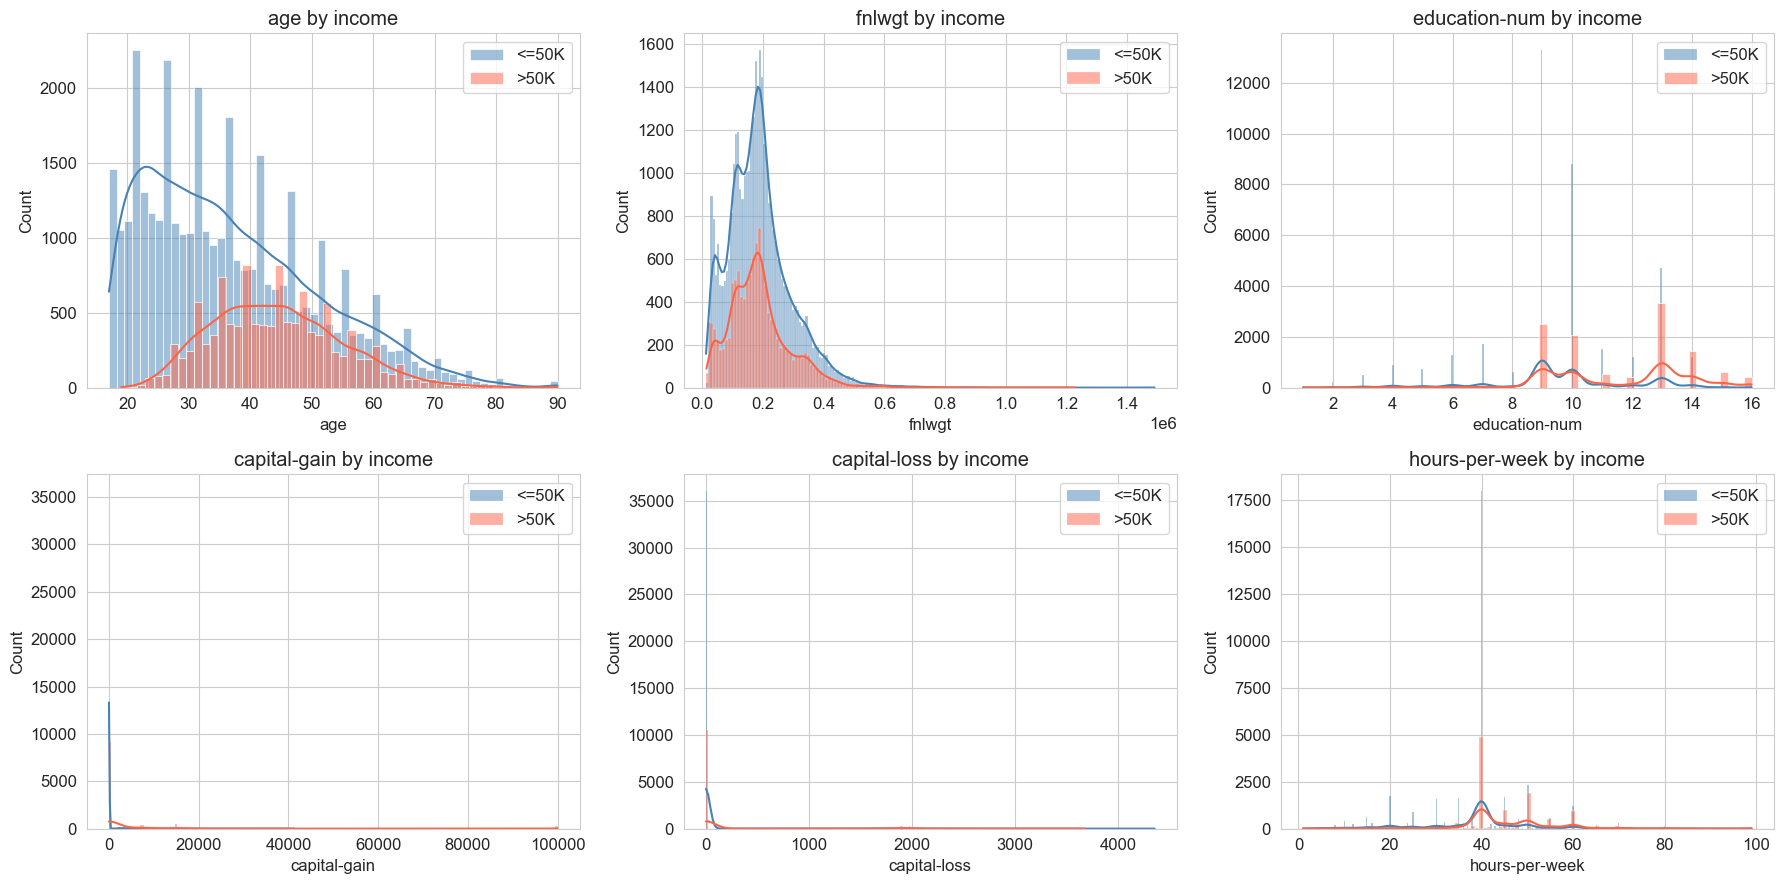

In [10]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    for label, color in [('<=50K', 'steelblue'), ('>50K', 'tomato')]:
        sns.histplot(df[df['income'] == label][col], kde=True, ax=ax,
                     color=color, edgecolor='white', alpha=0.5, label=label)
    ax.set_title(f'{col} by income')
    ax.set_xlabel(col)
    ax.legend()
plt.tight_layout()
plt.show()

**What jumps out:**

- **Age**: high-income individuals are noticeably older on average -- the red distribution sits to the right of the blue one. A tree might split on something like `age > 30`.
- **Education-num**: shifted right too -- a natural threshold split.
- **Hours-per-week**: high earners cluster at and above 40 hours/week; many low earners work part-time.
- **Capital-gain** and **capital-loss**: zero for almost everyone, but when they're non-zero, they're a *very* strong signal of high income. This is exactly the kind of sharp threshold a tree loves.
- **fnlwgt**: the two distributions are essentially identical. This is just a census sampling weight -- the tree should largely ignore it.

Boxplots make the same point more compactly:

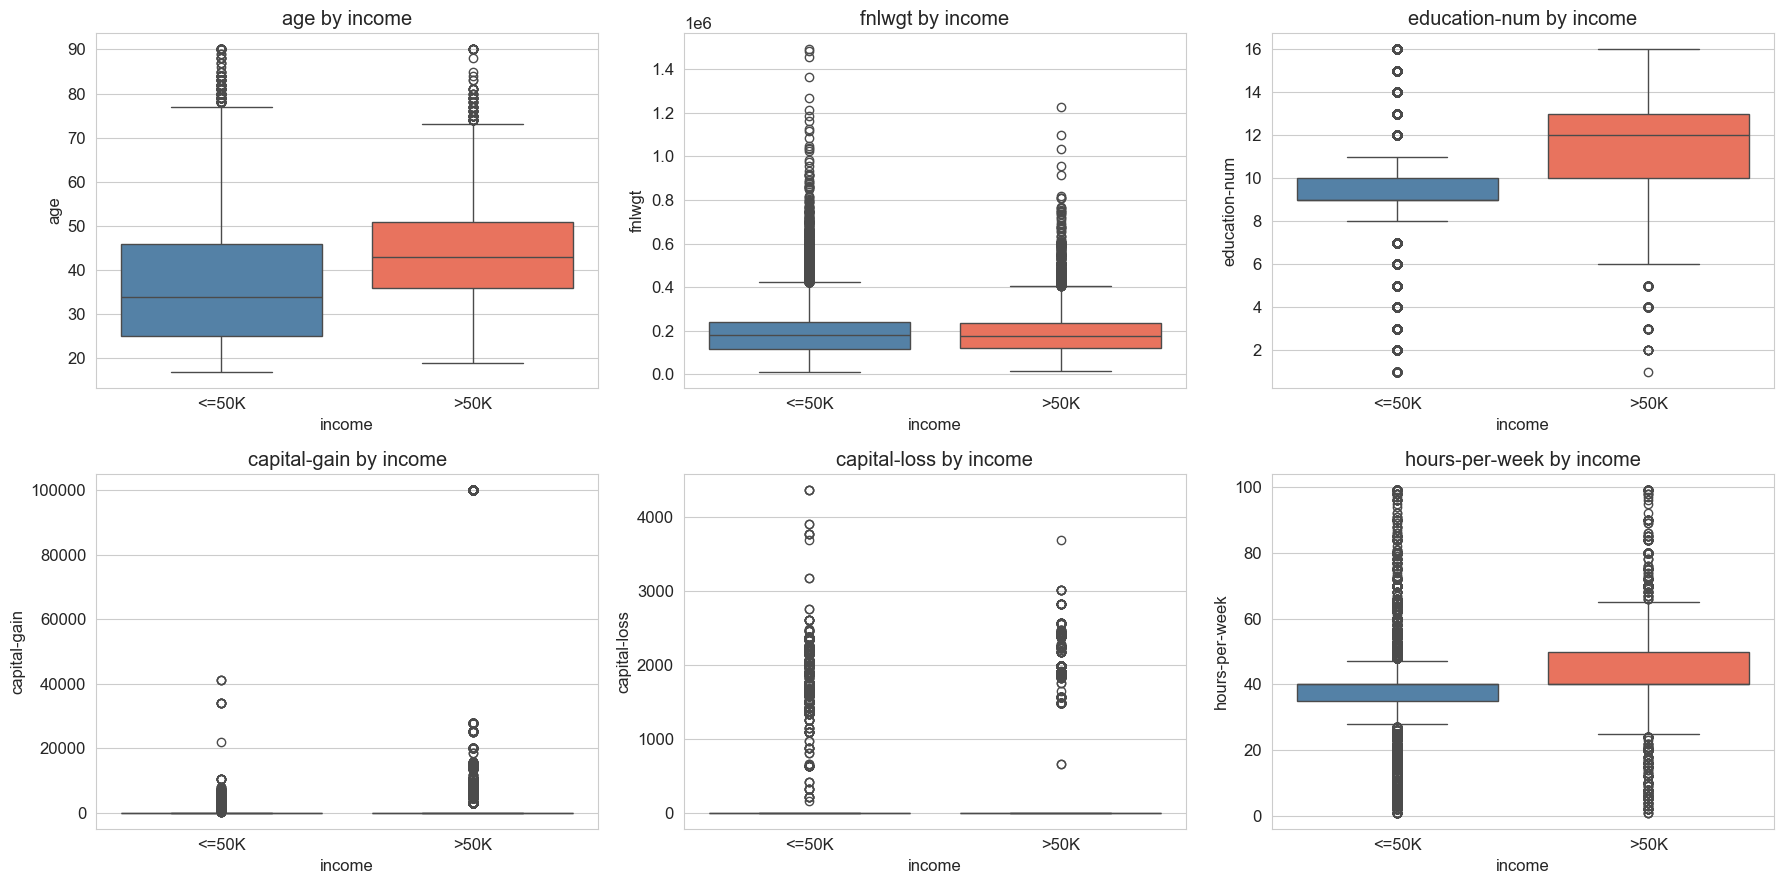

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x='income', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(f'{col} by income')
plt.tight_layout()
plt.show()

### 4.3 Categorical features vs income

For a categorical feature, the question is: *within each category, what fraction of people earn >\$50K?* If that fraction varies a lot between categories, the feature is informative.

The baseline rate across the whole dataset is ~24%, so we'll draw a reference line at that level. Anything well above 24% pushes income up; anything well below pushes it down.

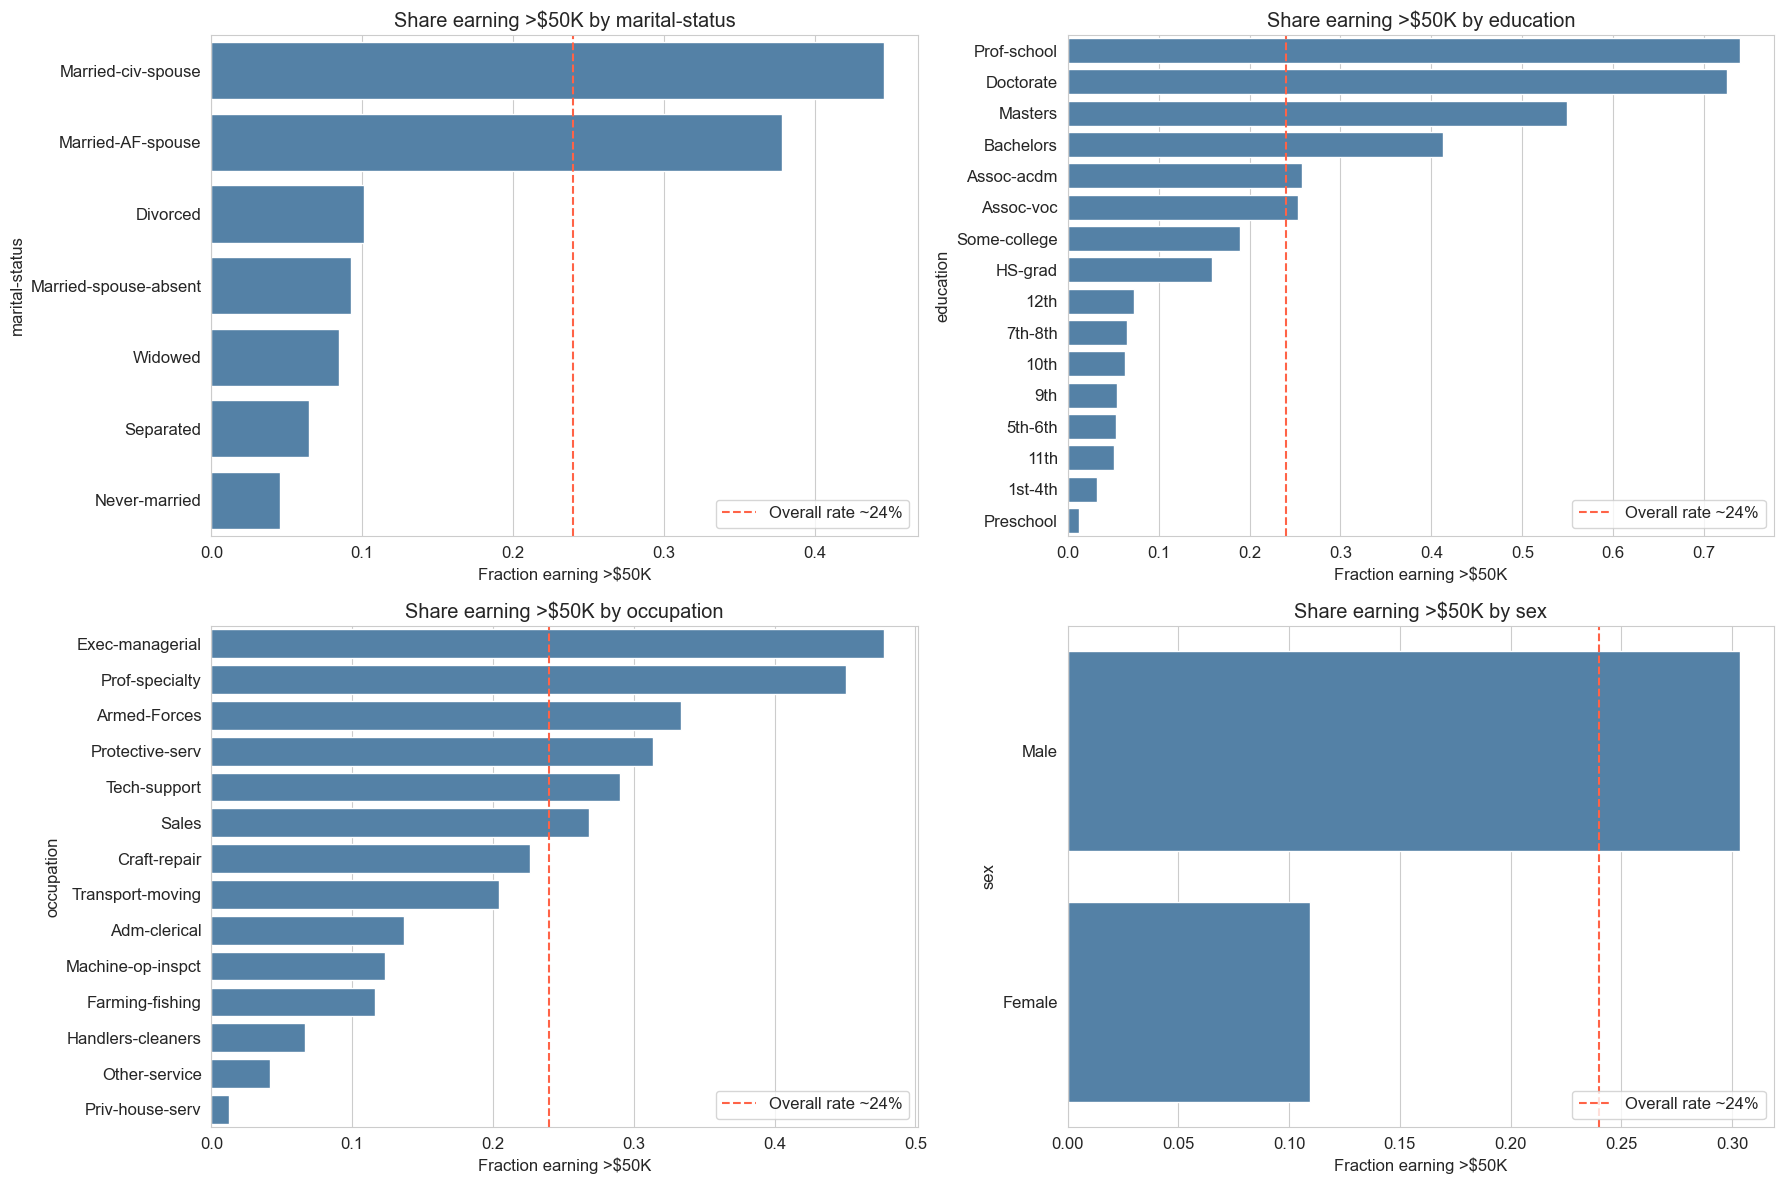

In [12]:
# the four categorical features we'd expect to matter most, based on intuition
quick_cats = ['marital-status', 'education', 'occupation', 'sex']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.ravel(), quick_cats):
    rate = (df.assign(high=(df['income'] == '>50K').astype(int))
              .groupby(col)['high'].mean()
              .sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, color='steelblue', ax=ax, edgecolor='white')
    ax.axvline(0.24, color='tomato', linestyle='--', linewidth=1.5, label='Overall rate ~24%')
    ax.set_title(f'Share earning >$50K by {col}')
    ax.set_xlabel('Fraction earning >$50K')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reading these:**

- **Marital status** is dramatic. Among `Married-civ-spouse`, almost half earn >\$50K. Among `Never-married`, it's less than 10%. This is one of the strongest single signals in the dataset -- expect it near the top of the tree.
- **Education** climbs steeply: only ~5% of high-school dropouts earn >\$50K, but ~75% of doctorates do.
- **Occupation** varies from ~7% (Priv-house-serv, farming) to ~50%+ (Exec-managerial, Prof-specialty).
- **Sex** shows a clear gap: ~30% of men vs ~11% of women earn >\$50K in this sample.

The other categorical features (`workclass`, `relationship`, `race`, `native-country`) follow similar patterns but with smaller groups.

### 4.4 Correlations among numeric features

Unlike logistic regression, a tree is unbothered by correlated features -- but the correlation matrix is still a quick way to see which numeric features track the target. We'll add a binary version of the target to the matrix so we can read off the point-biserial correlations:

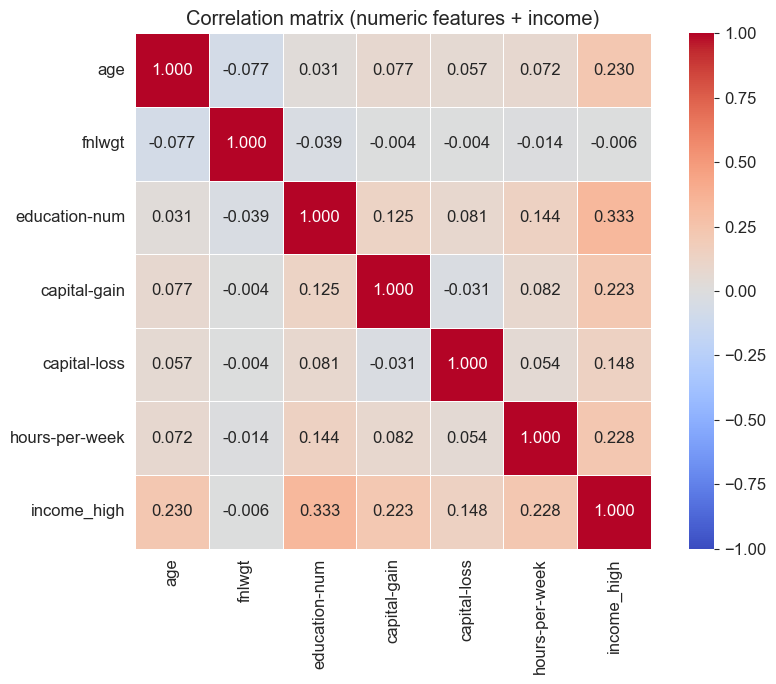

In [13]:
df_corr = df.copy()
df_corr['income_high'] = (df_corr['income'] == '>50K').astype(int)
corr = df_corr[numeric_cols + ['income_high']].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.3f', square=True)
plt.title('Correlation matrix (numeric features + income)')
plt.tight_layout()
plt.show()

`education-num`, `age`, and `hours-per-week` have the largest correlations with `income_high` (0.2-0.3 range). These will likely be among the tree's most important features. `fnlwgt` is essentially uncorrelated -- as expected.

We're done exploring. Time to prep the data.

## 5. Preparing the Data for Modelling

A decision tree needs less preprocessing than logistic regression -- in particular, **no standardisation**. Here's the full checklist:

| Step | Needed for a tree? | Why |
|------|--------------------|-----|
| 1. Drop rows with missing values | Yes | sklearn's tree can't consume NaNs |
| 2. Encode the target as 0/1 | Yes | sklearn expects numeric targets |
| 3. One-hot encode categoricals | Yes | sklearn's tree only consumes numbers |
| 4. ~~Standardise numeric features~~ | **No** | splits are threshold-based and scale-invariant |
| 5. Split into train/test (stratified) | Yes | to evaluate on unseen data, both classes represented |

We do one thing differently from the logistic-regression version: when we one-hot encode we **keep every category** (`drop_first=False`). A tree treats each indicator as its own candidate split, and there's no collinearity problem to avoid, so keeping all of them gives cleaner, more readable feature-importance results.

### 5.1 Drop missing values

In [14]:
before = df.shape[0]
df_clean = df.dropna().reset_index(drop=True)
print(f"Before: {before:,} rows  ->  After dropna: {df_clean.shape[0]:,} rows  ({(1 - df_clean.shape[0]/before)*100:.1f}% dropped)")

Before: 48,842 rows  ->  After dropna: 45,222 rows  (7.4% dropped)


### 5.2 Encode the target as 0/1

In [15]:
df_clean['income'] = (df_clean['income'].str.strip() == '>50K').astype(int)
print("Target now binary (1 = >$50K):")
print(df_clean['income'].value_counts().to_dict())

Target now binary (1 = >$50K):
{0: 34014, 1: 11208}


### 5.3 One-hot encode the categorical features

One-hot encoding turns a single categorical column with K values into K columns of 0/1 indicators. We keep all K (no `drop_first`) so each category is an independent yes/no question the tree can split on, and the feature-importance table later reads naturally.

In [16]:
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

df_enc = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# get_dummies produces bool columns -- cast to int so they play nicely with sklearn
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f"After one-hot encoding: {df_enc.shape[0]:,} rows x {df_enc.shape[1]:,} columns")
print(f"(Was {df_clean.shape[1]} columns; gained {df_enc.shape[1] - df_clean.shape[1]} from one-hot)")

After one-hot encoding: 45,222 rows x 105 columns
(Was 15 columns; gained 90 from one-hot)


### 5.4 Train/test split (stratified)

We hold out 30% of the data for testing, and pass `stratify=y` so the 76/24 class balance is preserved on both sides of the split. Because we're not scaling, there's nothing for the test set to leak into -- but the train/test discipline still matters for honest evaluation, and *especially* for trees, which overfit eagerly.

In [17]:
y = df_enc['income']
X = df_enc.drop('income', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Number of features: {X.shape[1]}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set : 31,655 samples
Test set     : 13,567 samples
Number of features: 104
Train class balance: {0: 0.752, 1: 0.248}
Test  class balance: {0: 0.752, 1: 0.248}


## How a Decision Tree Learns

Before fitting anything, let's understand what the algorithm actually does.

### Recursive binary splitting

A tree is built top-down and greedily. Starting with all the training data at the root, the algorithm:

1. Looks at every feature and every possible threshold.
2. Picks the single split (`feature ≤ value`) that best separates the two classes.
3. Repeats the process independently on each of the two resulting groups.
4. Stops when a group is pure (all one class), too small, or a depth limit is hit.

Each leaf then predicts the **majority class** of the training samples that landed in it (and a probability equal to the class proportion there).

### Measuring "best" -- impurity

To decide which split is best, the tree needs to score how *mixed* a group is. The default measure is **Gini impurity**:

$$\text{Gini} = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of class $k$ in the node. A pure node (all one class) has Gini = 0; a 50/50 node has Gini = 0.5 (the worst for two classes). The alternative, **entropy**, tells the same story on a different scale.

The tree chooses the split that produces the largest drop in impurity -- the **information gain**:

$$\text{gain} = \text{impurity(parent)} - \Big(\tfrac{n_L}{n}\,\text{impurity}(L) + \tfrac{n_R}{n}\,\text{impurity}(R)\Big)$$

### Why trees overfit

Left unconstrained, a tree keeps splitting until every leaf is pure -- effectively memorising the training data, including its noise. That gives ~100% training accuracy and much worse test accuracy. The cure is to **limit the tree's complexity**: `max_depth`, `min_samples_leaf`, and friends. We'll see the overfitting first-hand and then tune it away.

## 6. Building the Model

We'll build the tree in two passes:

- **6.1** A shallow tree (`max_depth=3`) that we can draw and read end to end. This is the clearest way to *see* what a tree does.
- **6.2** A fully grown tree, to watch it overfit -- then we'll control its depth.

### 6.1 A shallow, readable tree (max_depth = 3)

With the depth capped at 3, the whole model fits on one page. Let's fit it and look at the rules.

In [18]:
tree_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

print("--- Shallow tree (max_depth=3) ---")
print(f"Number of leaves : {tree_shallow.get_n_leaves()}")
print(f"Tree depth       : {tree_shallow.get_depth()}")
print(f"Train accuracy   : {tree_shallow.score(X_train, y_train):.4f}")
print(f"Test  accuracy   : {tree_shallow.score(X_test, y_test):.4f}")

--- Shallow tree (max_depth=3) ---
Number of leaves : 8
Tree depth       : 3
Train accuracy   : 0.8408
Test  accuracy   : 0.8360


Now the part trees are famous for -- we can draw the entire decision flowchart:

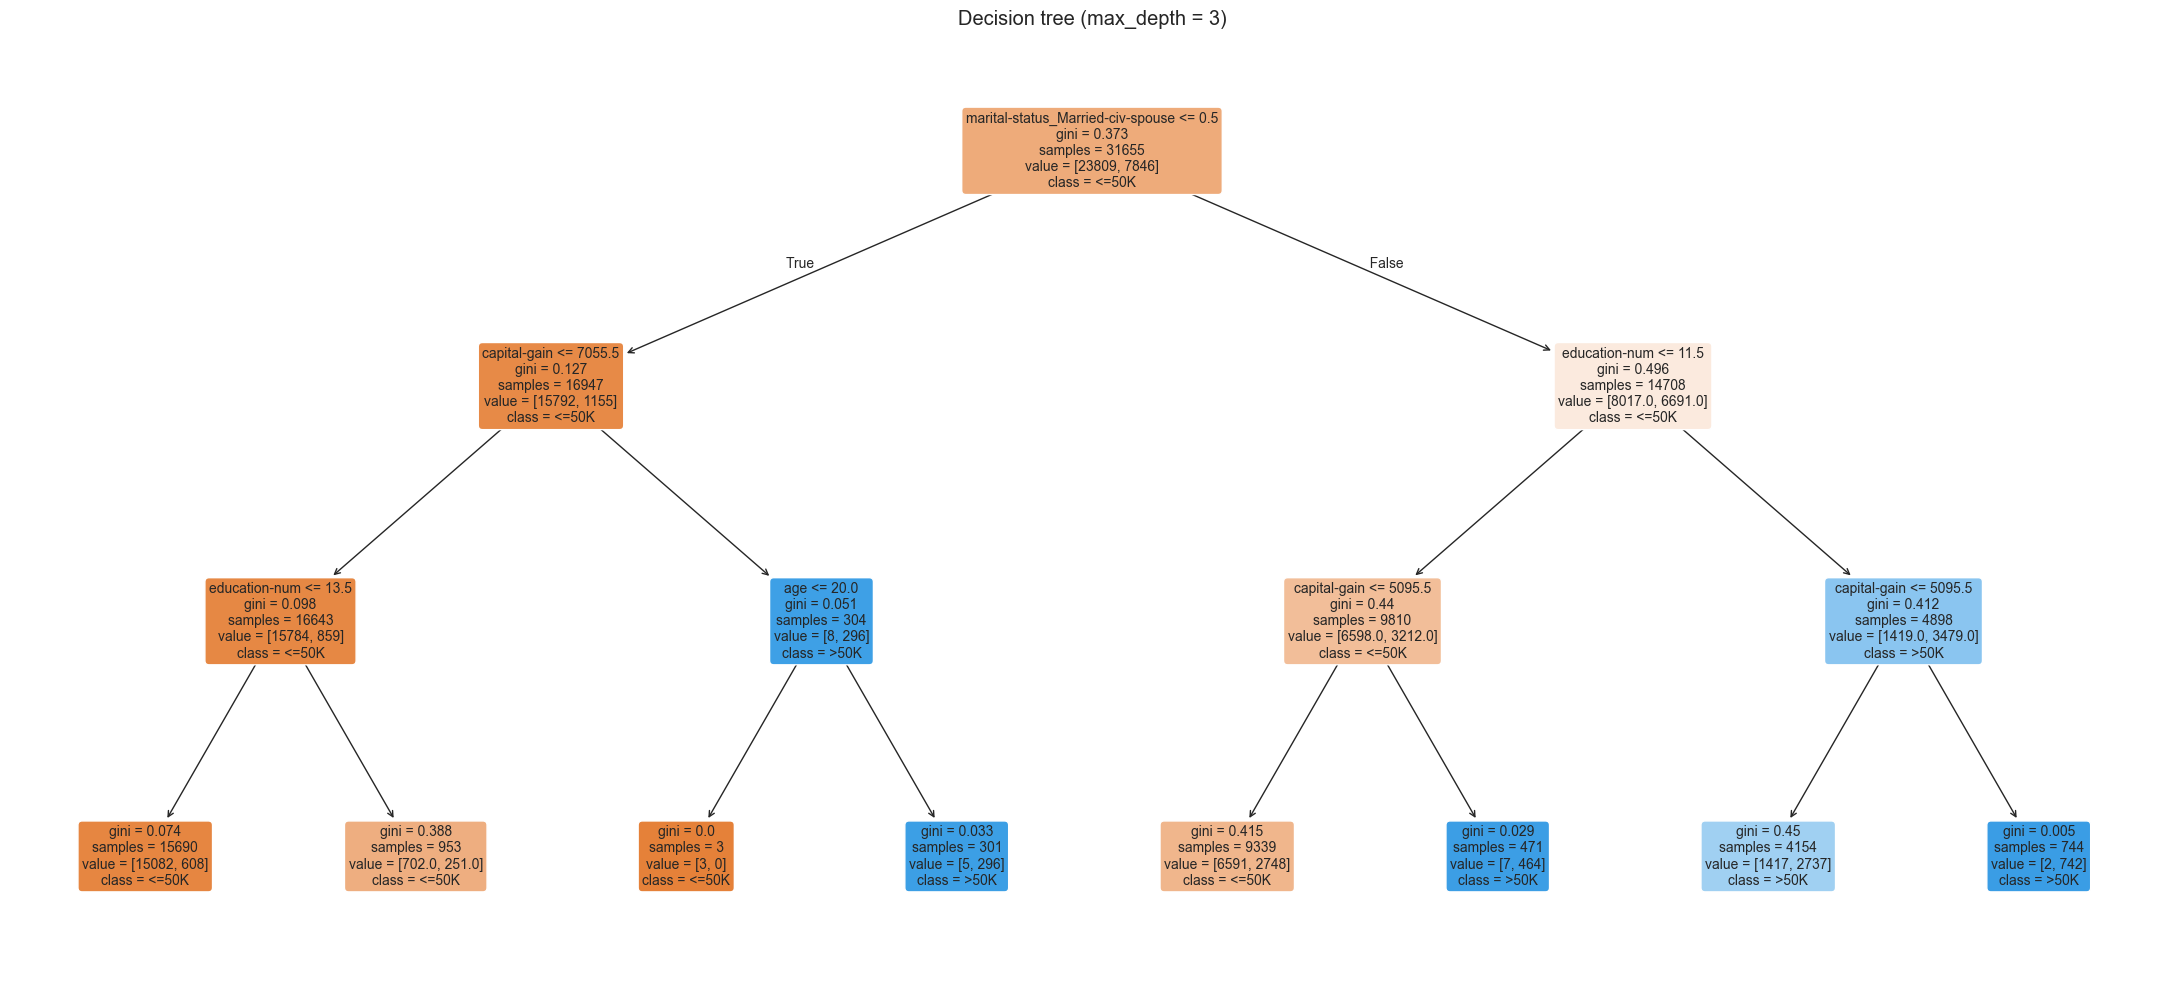

In [19]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_shallow,
    feature_names=X.columns,
    class_names=['<=50K', '>50K'],
    filled=True, rounded=True, fontsize=10, ax=ax,
)
ax.set_title('Decision tree (max_depth = 3)')
plt.tight_layout()
plt.show()

Reading the tree: start at the root, follow the **left** branch when the condition is true and the **right** branch when it's false, until you hit a leaf. The colour shows which class dominates (blue = `<=50K`, orange = `>50K`) and the intensity shows how pure the leaf is.

We can also dump the same logic as plain text -- handy for copying into a report or a code comment:

In [20]:
print(export_text(tree_shallow, feature_names=list(X.columns), max_depth=3))

|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital-gain <= 7055.50
|   |   |--- education-num <= 13.50
|   |   |   |--- class: 0
|   |   |--- education-num >  13.50
|   |   |   |--- class: 0
|   |--- capital-gain >  7055.50
|   |   |--- age <= 20.00
|   |   |   |--- class: 0
|   |   |--- age >  20.00
|   |   |   |--- class: 1
|--- marital-status_Married-civ-spouse >  0.50
|   |--- education-num <= 11.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- class: 0
|   |   |--- capital-gain >  5095.50
|   |   |   |--- class: 1
|   |--- education-num >  11.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- class: 1
|   |   |--- capital-gain >  5095.50
|   |   |   |--- class: 1



### A cleaner rendering with Graphviz

`plot_tree` is convenient, but **Graphviz** produces a crisper, publication-quality diagram with nicer box layout and edge routing. `export_graphviz` turns the fitted tree into DOT source, which the `graphviz` Python package renders inline.

> **Setup note.** The `graphviz` *Python* package needs the Graphviz *system* binaries as well. If the render below errors with "dot not found", install them once:
> - conda: `conda install -c conda-forge python-graphviz`
> - macOS: `brew install graphviz`
> - Debian/Ubuntu: `sudo apt-get install graphviz`

In [21]:
# import os, shutil
# # The graphviz PYTHON package shells out to the graphviz SYSTEM binary ('dot').
# # Install the binary once:  brew install graphviz   (or)   conda install -c conda-forge graphviz
# # This makes a freshly-installed 'dot' reachable even without restarting the kernel:
# if shutil.which('dot') is None:
#     for _p in ('/opt/homebrew/bin', '/usr/local/bin',
#                os.path.join(os.environ.get('CONDA_PREFIX', ''), 'bin')):
#         if os.path.isfile(os.path.join(_p, 'dot')):
#             os.environ['PATH'] = _p + os.pathsep + os.environ['PATH']
#             break

# from sklearn.tree import export_graphviz
# import graphviz

# dot_data = export_graphviz(
#     tree_shallow,
#     out_file=None,
#     feature_names=list(X.columns),
#     class_names=['<=50K', '>50K'],
#     filled=True, rounded=True, special_characters=True,
#     proportion=True,          # show class proportions instead of raw counts
# )

# graph = graphviz.Source(dot_data)

# # save a PNG alongside the notebook (optional) and render inline
# graph.render('decision_tree_shallow', format='png', cleanup=True)
# graph

Notice what the tree picked for its very first split -- it'll be one of the strong signals we saw in EDA (typically `marital-status_Married-civ-spouse`, `capital-gain`, or `education-num`). The greedy algorithm independently rediscovered what our exploratory plots suggested.

### 6.2 A fully grown tree -- watch it overfit

Now we remove the depth limit and let the tree grow until every leaf is pure. Watch the gap between training and test accuracy.

In [22]:
tree_full = DecisionTreeClassifier(random_state=42)   # no depth limit
tree_full.fit(X_train, y_train)

print("--- Fully grown tree (no limit) ---")
print(f"Number of leaves : {tree_full.get_n_leaves():,}")
print(f"Tree depth       : {tree_full.get_depth()}")
print(f"Train accuracy   : {tree_full.score(X_train, y_train):.4f}")
print(f"Test  accuracy   : {tree_full.score(X_test, y_test):.4f}")

--- Fully grown tree (no limit) ---
Number of leaves : 4,624
Tree depth       : 54
Train accuracy   : 1.0000
Test  accuracy   : 0.8117


There it is: **near-perfect training accuracy but noticeably worse test accuracy**, with thousands of leaves. The tree memorised the training set. A shallow tree underfits; a fully grown one overfits. The sweet spot is somewhere in between -- let's find it.

### 6.3 Tuning the depth

We sweep `max_depth` from 1 to 25 and record training vs test accuracy at each setting. The point where test accuracy peaks (and starts to diverge from training accuracy) is the depth we want.

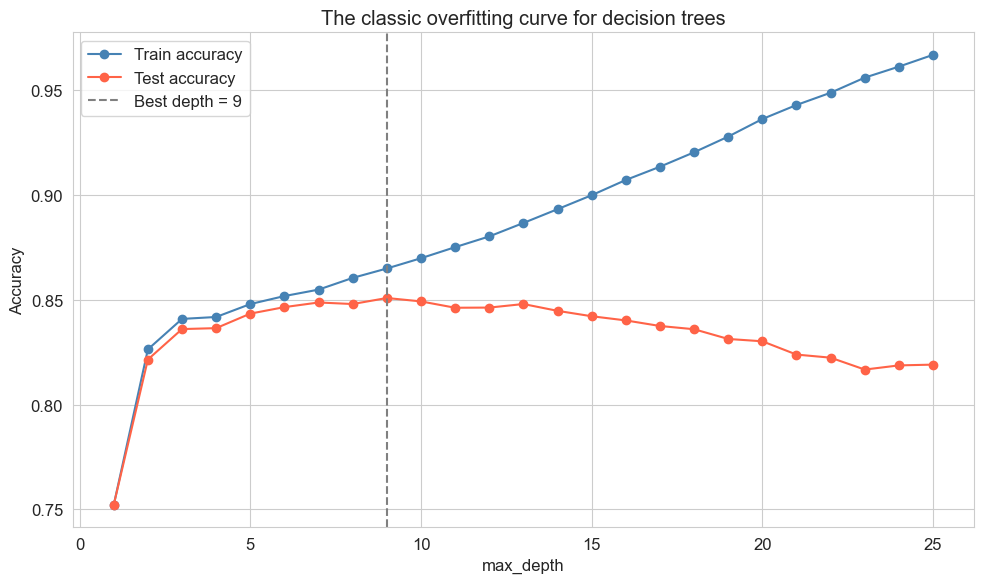

Best test accuracy 0.8508 at max_depth = 9


In [23]:
depths = range(1, 26)
train_scores, test_scores = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_scores.append(t.score(X_train, y_train))
    test_scores.append(t.score(X_test, y_test))

best_depth = depths[int(np.argmax(test_scores))]

plt.figure(figsize=(10, 6))
plt.plot(list(depths), train_scores, 'o-', color='steelblue', label='Train accuracy')
plt.plot(list(depths), test_scores,  'o-', color='tomato',   label='Test accuracy')
plt.axvline(best_depth, color='grey', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('The classic overfitting curve for decision trees')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best test accuracy {max(test_scores):.4f} at max_depth = {best_depth}")

The two curves tell the whole story. Training accuracy climbs relentlessly toward 1.0 as the tree gets deeper. Test accuracy rises, **peaks**, then sags as the tree starts fitting noise. We'll fix `max_depth` at that peak and also set `min_samples_leaf` so no leaf is built from a tiny, unreliable handful of samples.

In [24]:
tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=20,
    random_state=42,
)
tree.fit(X_train, y_train)

print("--- Tuned decision tree ---")
print(f"max_depth        : {best_depth}")
print(f"min_samples_leaf : 20")
print(f"Number of leaves : {tree.get_n_leaves():,}")
print(f"Train accuracy   : {tree.score(X_train, y_train):.4f}")
print(f"Test  accuracy   : {tree.score(X_test, y_test):.4f}")

--- Tuned decision tree ---
max_depth        : 9
min_samples_leaf : 20
Number of leaves : 144
Train accuracy   : 0.8609
Test  accuracy   : 0.8505


## 7. Model Evaluation

For a classifier we look at several metrics in turn, because each one tells a different story.

| Metric | What it measures | When it matters |
|--------|------------------|-----------------|
| **Accuracy**  | Fraction of correct predictions overall | Easy to read but misleading on imbalanced data |
| **Precision** | Of the people we *labelled* high-income, what fraction actually are | When false positives are costly |
| **Recall**    | Of the people who actually are high-income, what fraction we catch | When false negatives are costly |
| **F1**        | Harmonic mean of precision and recall | When you need a single number on imbalanced data |
| **ROC-AUC**   | Ranking quality across all thresholds | Threshold-independent measure of separability |

Let's compute them on the tuned tree.

In [25]:
y_pred  = tree.predict(X_test)
y_proba = tree.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print("--- Tuned tree -- test-set performance ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1        : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

--- Tuned tree -- test-set performance ---
Accuracy  : 0.8505
Precision : 0.7824
Recall    : 0.5497
F1        : 0.6457
ROC-AUC   : 0.9009


sklearn also gives us a tidy per-class breakdown in `classification_report`. This is usually the first thing to look at after fitting a classifier:

In [26]:
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.91     10205
        >50K       0.78      0.55      0.65      3362

    accuracy                           0.85     13567
   macro avg       0.82      0.75      0.78     13567
weighted avg       0.84      0.85      0.84     13567



How does the tuned tree compare to the shallow and fully-grown versions?

In [27]:
def metrics_row(model):
    yp = model.predict(X_test)
    yp_proba = model.predict_proba(X_test)[:, 1]
    return [accuracy_score(y_test, yp), precision_score(y_test, yp),
            recall_score(y_test, yp), f1_score(y_test, yp),
            roc_auc_score(y_test, yp_proba)]

comparison = pd.DataFrame(
    [metrics_row(tree_shallow), metrics_row(tree_full), metrics_row(tree)],
    columns=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    index=['Shallow (depth=3)', 'Fully grown', f'Tuned (depth={best_depth})'],
).round(4)
print(comparison.to_string())

                   Accuracy  Precision  Recall      F1  ROC-AUC
Shallow (depth=3)    0.8360     0.7384  0.5238  0.6128   0.8518
Fully grown          0.8117     0.6174  0.6318  0.6245   0.7514
Tuned (depth=9)      0.8505     0.7824  0.5497  0.6457   0.9009


The shallow tree underfits (high precision but it's too cautious). The fully grown tree overfits (its test metrics, especially ROC-AUC, suffer because pure leaves give over-confident 0/1 probabilities). The **tuned tree** gives the best balance -- the highest F1 and ROC-AUC of the three.

## 8. Diagnostic Plots -- where is the model right and wrong?

Three diagnostics worth looking at for any classifier:

1. **Confusion matrix** -- the raw counts of right and wrong predictions, by class.
2. **ROC curve** -- the trade-off between true-positive rate and false-positive rate as we change the threshold.
3. **Precision-Recall curve** -- a better alternative to ROC on imbalanced data.

### 8.1 Confusion matrix

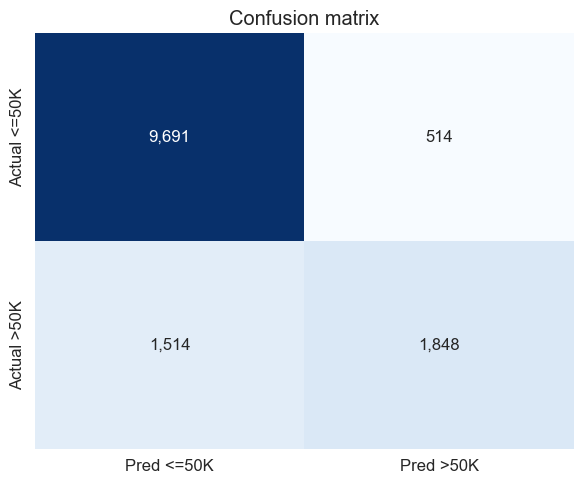

True negatives  (correctly low-income)   : 9,691
False positives (low-income, called high): 514
False negatives (high-income, missed)    : 1,514
True positives  (correctly high-income)  : 1,848


In [28]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'], ax=ax)
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives  (correctly low-income)   : {tn:,}")
print(f"False positives (low-income, called high): {fp:,}")
print(f"False negatives (high-income, missed)    : {fn:,}")
print(f"True positives  (correctly high-income)  : {tp:,}")

As with most models on this imbalanced dataset, the tree misses more high-income people (false negatives) than it incorrectly flags low-income ones. If false negatives were costly we could lower the decision threshold, or pass `class_weight='balanced'` when fitting the tree to make the minority class count for more.

### 8.2 ROC curve and Precision-Recall curve

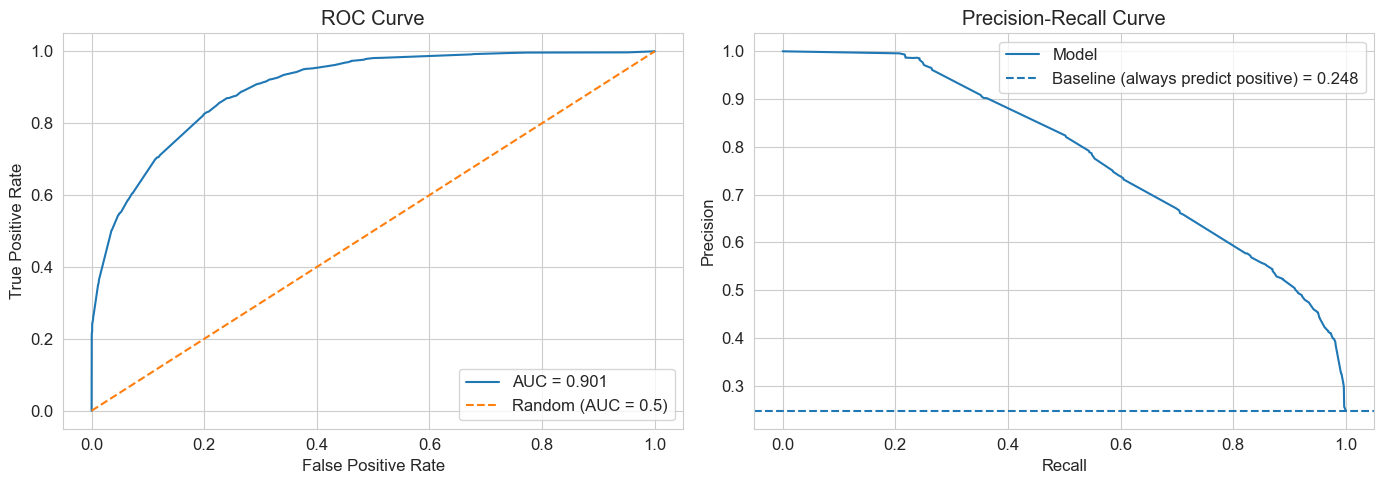

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_curve, prec_curve, label='Model')
axes[1].axhline(y_test.mean(), linestyle='--',
                label=f'Baseline (always predict positive) = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

**ROC curve.** Each point is a different decision threshold. The curve bowing up toward the top-left says the tree's probability scores genuinely separate the classes. (A single shallow tree gives a slightly "steppy" curve because it produces only a handful of distinct probability values -- one per leaf.)

**Precision-Recall curve.** Stays well above the 24% baseline. On imbalanced data this curve is often more informative than ROC, because it directly answers a practical question: if I act on the model's positive predictions, how clean are they?

## 9. Interpreting the Tree

This is where decision trees shine. Two complementary views:

- **Feature importances** -- a single number per feature, summarising how much it reduced impurity across all its splits.
- **The tree structure itself** -- the actual rules, which we already drew for the shallow tree.

### Feature importances

sklearn computes importance as the total impurity decrease contributed by each feature, weighted by how many samples pass through its splits, normalised to sum to 1. Higher = more decisive.

In [30]:
importances = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : tree.feature_importances_,
}).sort_values('Importance', ascending=False)

print("--- Top 15 most important features ---")
print(importances.head(15).round(4).to_string(index=False))

--- Top 15 most important features ---
                          Feature  Importance
marital-status_Married-civ-spouse      0.4118
                    education-num      0.2219
                     capital-gain      0.1905
                     capital-loss      0.0599
                              age      0.0416
                   hours-per-week      0.0263
       occupation_Exec-managerial      0.0161
                education_HS-grad      0.0067
       workclass_Self-emp-not-inc      0.0057
                           fnlwgt      0.0050
         occupation_Other-service      0.0049
                         sex_Male      0.0028
                       sex_Female      0.0025
              education_Bachelors      0.0012
     native-country_United-States      0.0012


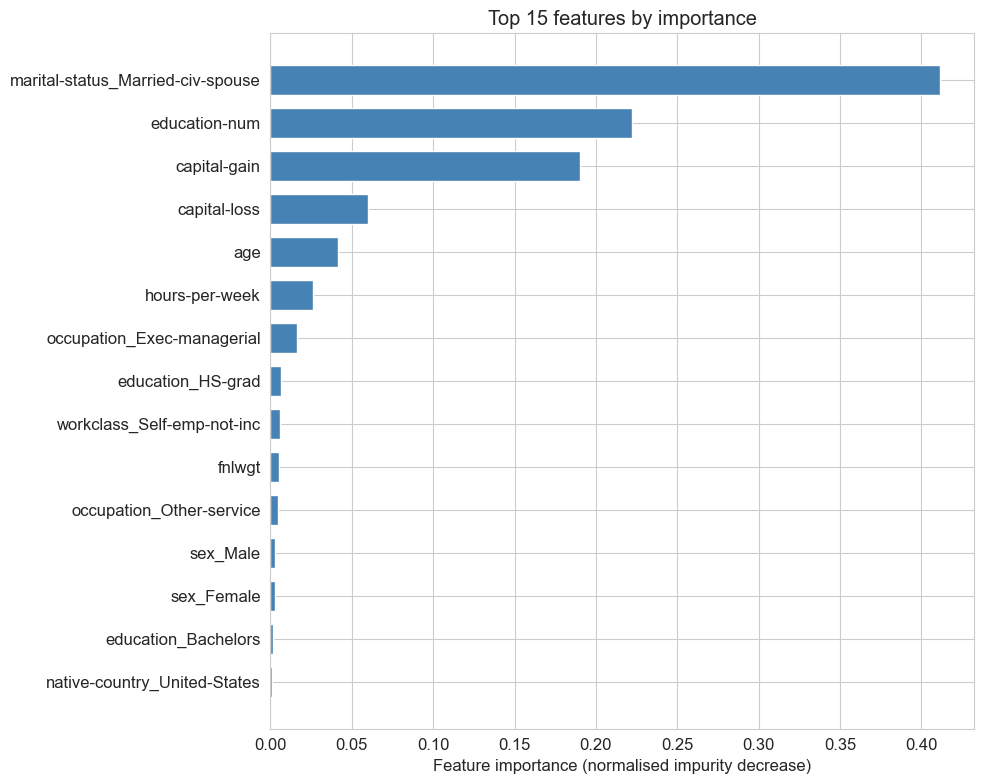

In [31]:
top15 = importances.head(15).sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top15['Feature'], top15['Importance'], color='steelblue', edgecolor='white', height=0.7)
ax.set_xlabel('Feature importance (normalised impurity decrease)')
ax.set_title('Top 15 features by importance')
plt.tight_layout()
plt.show()

**Reading what the tree learned:**

- The top features line up closely with what EDA predicted: `marital-status_Married-civ-spouse`, `capital-gain`, `education-num`, `age`, and `hours-per-week` typically dominate.
- Importance reflects how much *work* a feature does in separating classes, summed over the whole tree -- not a direction. Unlike logistic-regression coefficients there's no "+/-" sign here; to see direction you read the actual split rules.
- `fnlwgt` sits near the bottom, exactly as we expected from the overlapping distributions in EDA.

**A caveat on impurity-based importance.** It tends to inflate the apparent importance of high-cardinality numeric features (which offer many candidate thresholds). For a fairer ranking you can use permutation importance (`sklearn.inspection.permutation_importance`), which measures how much test performance drops when a feature is shuffled.

### Cross-validation -- is the score stable?

A single train/test split can be lucky or unlucky. A quick 5-fold cross-validation on the tuned tree's settings tells us how much the score wobbles across different splits.

In [32]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=20, random_state=42),
    X, y, cv=5, scoring='roc_auc',
)
print(f"5-fold ROC-AUC: {cv_scores.round(4)}")
print(f"Mean = {cv_scores.mean():.4f}  |  Std = {cv_scores.std():.4f}")

5-fold ROC-AUC: [0.9067 0.9029 0.9011 0.9037 0.9062]
Mean = 0.9041  |  Std = 0.0021


A tight spread across folds means the model's performance is stable and not an artifact of one particular split.

## 10. Persisting the Model to Disk

Training is the expensive part -- once we have a good tree we want to **save it** so we can reload and predict later without refitting. The standard tool is `joblib`, which serialises any Python/sklearn object to a binary file (it's a smarter `pickle` that handles large NumPy arrays efficiently).

We'll save the model, reload it, confirm the reloaded copy predicts identically, and then crack the file open to see **exactly what got stored**.

### 10.1 Save and reload

In [33]:
import joblib, os

MODEL_PATH = 'decision_tree_income.joblib'

# save the fitted estimator
joblib.dump(tree, MODEL_PATH)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Saved '{MODEL_PATH}'  ({size_kb:.1f} KB on disk)")

# reload it into a fresh object
tree_loaded = joblib.load(MODEL_PATH)

# prove the reloaded model is identical: same predictions on the test set
same = (tree_loaded.predict(X_test) == tree.predict(X_test)).all()
print(f"Reloaded model gives identical predictions: {same}")
print(f"Reloaded model test accuracy: {tree_loaded.score(X_test, y_test):.4f}")

Saved 'decision_tree_income.joblib'  (26.4 KB on disk)
Reloaded model gives identical predictions: True
Reloaded model test accuracy: 0.8505


### 10.2 What exactly is stored?

A pickled estimator is just the Python object's attributes frozen to disk. For a `DecisionTreeClassifier` that's two kinds of thing:

1. **The hyperparameters** you set (`max_depth`, `min_samples_leaf`, ...) -- the configuration.
2. **The learned state** from `fit()` -- the classes, the feature names, and most importantly the `tree_` object: a set of parallel NumPy arrays that *are* the tree.

Let's list the fitted attributes first (sklearn marks learned attributes with a trailing underscore):

In [34]:
print("--- Hyperparameters (the config you chose) ---")
for k, v in tree.get_params().items():
    print(f"  {k:24s}: {v}")

print("\n--- Learned attributes (set by .fit) ---")
print(f"  classes_         : {tree_loaded.classes_}")
print(f"  n_features_in_   : {tree_loaded.n_features_in_}")
print(f"  n_classes_       : {tree_loaded.n_classes_}")
print(f"  feature_names_in : {list(tree_loaded.feature_names_in_[:5])} ... ({len(tree_loaded.feature_names_in_)} total)")

--- Hyperparameters (the config you chose) ---
  ccp_alpha               : 0.0
  class_weight            : None
  criterion               : gini
  max_depth               : 9
  max_features            : None
  max_leaf_nodes          : None
  min_impurity_decrease   : 0.0
  min_samples_leaf        : 20
  min_samples_split       : 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst           : None
  random_state            : 42
  splitter                : best

--- Learned attributes (set by .fit) ---
  classes_         : [0 1]
  n_features_in_   : 104
  n_classes_       : 2
  feature_names_in : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'] ... (104 total)


### 10.3 The `tree_` object -- the actual tree, as arrays

The whole tree is stored in `tree.tree_` as a handful of arrays, all indexed by node id (node 0 is the root). For every node we get:

| Array | Meaning |
|-------|---------|
| `feature[i]`        | which feature node *i* splits on (`-2` = leaf, no split) |
| `threshold[i]`      | the split value: go left if `feature ≤ threshold` |
| `children_left[i]`  | node id of the left child (`-1` = leaf) |
| `children_right[i]` | node id of the right child (`-1` = leaf) |
| `value[i]`          | class counts of the training samples in node *i* |
| `n_node_samples[i]` | how many training samples reached node *i* |
| `impurity[i]`       | the node's Gini impurity |

These arrays are *all* that `predict` needs -- inference is just walking them from the root. Let's confirm the sizes and look at the root node:

In [35]:
t = tree_loaded.tree_

print(f"Total nodes in the tree : {t.node_count}")
print(f"Tree depth              : {tree_loaded.get_depth()}")
print(f"Number of leaves        : {tree_loaded.get_n_leaves()}\n")

print("Arrays that make up the tree (each has length = node_count):")
for name in ['feature', 'threshold', 'children_left', 'children_right', 'n_node_samples', 'impurity']:
    arr = getattr(t, name)
    print(f"  tree_.{name:15s} shape={arr.shape}  dtype={arr.dtype}")
print(f"  tree_.{'value':15s} shape={t.value.shape}  dtype={t.value.dtype}   (per-node class distribution)")

# decode the root node (id 0)
root_feat = t.feature[0]
print("\n--- Root node (id 0) ---")
print(f"  splits on feature #{root_feat}  =  '{X.columns[root_feat]}'")
print(f"  rule: go LEFT if  {X.columns[root_feat]} <= {t.threshold[0]:.3f}")
print(f"  samples at root  : {t.n_node_samples[0]:,}")
print(f"  class counts     : {t.value[0].ravel()}  (<=50K, >50K)")
print(f"  Gini impurity    : {t.impurity[0]:.4f}")

Total nodes in the tree : 287
Tree depth              : 9
Number of leaves        : 144

Arrays that make up the tree (each has length = node_count):
  tree_.feature         shape=(287,)  dtype=int64
  tree_.threshold       shape=(287,)  dtype=float64
  tree_.children_left   shape=(287,)  dtype=int64
  tree_.children_right  shape=(287,)  dtype=int64
  tree_.n_node_samples  shape=(287,)  dtype=int64
  tree_.impurity        shape=(287,)  dtype=float64
  tree_.value           shape=(287, 1, 2)  dtype=float64   (per-node class distribution)

--- Root node (id 0) ---
  splits on feature #31  =  'marital-status_Married-civ-spouse'
  rule: go LEFT if  marital-status_Married-civ-spouse <= 0.500
  samples at root  : 31,655
  class counts     : [0.75214026 0.24785974]  (<=50K, >50K)
  Gini impurity    : 0.3729


So "saving the model" really means **saving these arrays plus the hyperparameters** -- nothing about the training data itself is kept, only the learned splits. That's why the file is small and why the reloaded model predicts identically: every number `predict` relies on is in `tree_`.

One practical caveat: a pickle/joblib file is tied to the library versions used to create it. Reloading with a very different scikit-learn version can warn or break, so for long-term storage it's good practice to record the versions alongside the file:

In [36]:
import sklearn, joblib
print(f"scikit-learn : {sklearn.__version__}")
print(f"joblib       : {joblib.__version__}")
print("\nKeep these versions with the saved model so it can be reloaded reliably later.")

scikit-learn : 1.8.0
joblib       : 1.5.3

Keep these versions with the saved model so it can be reloaded reliably later.


## 11. Summary

Here's the full pipeline at a glance:

| Step | What we did |
|------|------------|
| Load | Pulled 48,842 rows from OpenML |
| Describe | 6 numeric + 8 categorical features, ~7% missing, classes imbalanced 76/24 |
| EDA | Class-conditional histograms, boxplots, categorical share plots, correlation matrix |
| Prep | Dropped missing rows → encoded target → one-hot encoded categoricals → **no scaling needed** → stratified split |
| Shallow tree | `max_depth=3`: fully readable flowchart, mild underfit |
| Full tree | No limit: ~100% train accuracy but overfits badly |
| Tuning | Swept `max_depth`, picked the peak of the test-accuracy curve, added `min_samples_leaf` |
| Evaluation | Accuracy / precision / recall / F1 / ROC-AUC + classification report |
| Diagnostics | Confusion matrix, ROC, PR curve |
| Interpret | Feature importances + the tree's own split rules; cross-validation for stability |
| Persist | Saved with `joblib`, reloaded identically, inspected the `tree_` arrays that *are* the model |

**The big lessons.**

1. **Trees ask questions, they don't draw lines.** That makes them scale-free (no standardising) and naturally able to capture interactions, at the cost of axis-aligned, "boxy" decision boundaries.
2. **An unconstrained tree will overfit.** The train-vs-test accuracy curve is the canonical picture of the bias-variance trade-off -- always plot it.
3. **A single tree is wonderfully interpretable but rarely the strongest model.** The natural next step is to combine many trees -- bagging, **random forests**, and **gradient boosting** -- which trade away some of this interpretability for substantially better accuracy.